In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# Load the dataset
df = pd.read_csv('drive/MyDrive/merfish.csv', index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/merfish.csv'

In [ ]:
df = df.reset_index()

In [ ]:
df.shape()

,class,brain_section_label,x,y,Prkcq,Col5a1,Grik3,Igfbp2,Osr1,Syt6,...,Blank-16,Blank-32,Blank-18,Blank-4,Blank-28,Blank-33,Blank-34,Blank-45,Blank-23,Blank-48
0,04 DG-IMN Glut,C57BL6J-638850.37,7.226245,4.148963,0.000000,0.000000,0.000000,0.00000,0.000000,1.225414,...,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.00000
1,23 P Glut,C57BL6J-638850.26,5.064889,7.309543,0.000000,1.208782,3.522482,0.00000,0.000000,3.037880,...,0.0,0.727452,0.0,0.00000,0.727452,0.0,0.000000,0.0,0.000000,0.00000
2,23 P Glut,C57BL6J-638850.25,5.792921,8.189973,0.000000,0.701980,3.886373,0.70198,0.000000,2.980773,...,0.0,0.000000,0.0,0.70198,0.000000,0.0,1.172149,0.0,0.000000,0.70198
3,23 P Glut,C57BL6J-638850.13,3.195950,5.868655,0.000000,0.000000,2.757778,0.00000,0.497414,1.612780,...,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.497414,0.00000
4,23 P Glut,C57BL6J-638850.27,5.635732,7.995842,1.205327,0.000000,1.454804,0.00000,0.521350,2.297979,...,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.00000


In [ ]:
num_classes = df["class"].nunique()
print(f"Class 总数: {num_classes}")

Class 总数: 34


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


# df.shape = (N, 554)  # 550 gene + class + x + y + brain_section

gene_features = df.iloc[:, -550:].values.astype(np.float32)  # shape: (N, 550)

# 对 class 列进行 label encoding
le = LabelEncoder()
class_labels = le.fit_transform(df["class"])  # shape: (N,)

# 转为 tensor
X = torch.tensor(gene_features)
y = torch.tensor(class_labels, dtype=torch.long)

# train/val 划分
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# 封装成 DataLoader
batch_size = 1024
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

NameError: name 'df' is not defined

In [ ]:
all_loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.fc2 = nn.Linear(1024, 2048)
        self.bn2 = nn.BatchNorm1d(2048)

        self.fc3 = nn.Linear(2048, 512)
        self.bn3 = nn.BatchNorm1d(512)

        self.fc4 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x

# 初始化模型
model = MLPClassifier(in_dim=550, num_classes=34)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [ ]:
from tqdm import tqdm
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False)

    for xb, yb in train_bar:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item() * xb.size(0)
        train_loss += batch_loss

        train_bar.set_postfix(loss=loss.item())

    # 验证阶段
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]", leave=False)

    with torch.no_grad():
        for xb, yb in val_bar:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            batch_loss = loss.item() * xb.size(0)
            val_loss += batch_loss
            correct += (pred.argmax(1) == yb).sum().item()
            total += yb.size(0)

            val_bar.set_postfix(loss=loss.item())

    # 最终打印汇总结果
    print(f"[Epoch {epoch+1:02d}] "
          f"Train Loss: {train_loss / len(X_train):.4f} | "
          f"Val Loss: {val_loss / len(X_val):.4f} | "
          f"Val Acc: {correct / total:.4f}")


[Epoch 01] Train Loss: 0.0549 | Val Loss: 0.0339 | Val Acc: 0.9872


[Epoch 02] Train Loss: 0.0293 | Val Loss: 0.0286 | Val Acc: 0.9893


[Epoch 03] Train Loss: 0.0238 | Val Loss: 0.0275 | Val Acc: 0.9896


[Epoch 04] Train Loss: 0.0196 | Val Loss: 0.0258 | Val Acc: 0.9903


[Epoch 05] Train Loss: 0.0164 | Val Loss: 0.0267 | Val Acc: 0.9902


[Epoch 06] Train Loss: 0.0136 | Val Loss: 0.0271 | Val Acc: 0.9903


[Epoch 07] Train Loss: 0.0115 | Val Loss: 0.0283 | Val Acc: 0.9905


KeyboardInterrupt: 

In [ ]:
dataloader = all_loader
model.eval()
all_probs = []

with torch.no_grad():
    for x_batch, _ in dataloader:
        x_batch = x_batch.to(device)
        output = model(x_batch)
        probs = torch.softmax(output, dim=1)
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)  # [num_cells, num_classes]

probs_np = all_probs.numpy()

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix

pred_labels = probs_np.argmax(axis=1)  # [num_cells]
#true_labels_encoded = le.fit_transform(y_val)

# Step 3 - confusion matrix
cm = confusion_matrix(y_val, pred_labels)

# 可选：打印 class names
print("Classes:", le.classes_)
print("Confusion Matrix:\n", cm)

Classes: ['01 IT-ET Glut' '02 NP-CT-L6b Glut' '03 OB-CR Glut' '04 DG-IMN Glut'
 '05 OB-IMN GABA' '06 CTX-CGE GABA' '07 CTX-MGE GABA' '08 CNU-MGE GABA'
 '09 CNU-LGE GABA' '10 LSX GABA' '11 CNU-HYa GABA' '12 HY GABA'
 '13 CNU-HYa Glut' '14 HY Glut' '15 HY Gnrh1 Glut' '16 HY MM Glut'
 '17 MH-LH Glut' '18 TH Glut' '19 MB Glut' '20 MB GABA' '21 MB Dopa'
 '22 MB-HB Sero' '23 P Glut' '24 MY Glut' '25 Pineal Glut' '26 P GABA'
 '27 MY GABA' '28 CB GABA' '29 CB Glut' '30 Astro-Epen' '31 OPC-Oligo'
 '32 OEC' '33 Vascular' '34 Immune']
Confusion Matrix:
 [[134986     63      2 ...      0     45     17]
 [   252  34047      0 ...      0     16      9]
 [     0      0   2373 ...      0      2      0]
 ...
 [     0      0      0 ...   2430     24      1]
 [    33      2      0 ...      5  89519     25]
 [    12      2      0 ...      0     27  10606]]


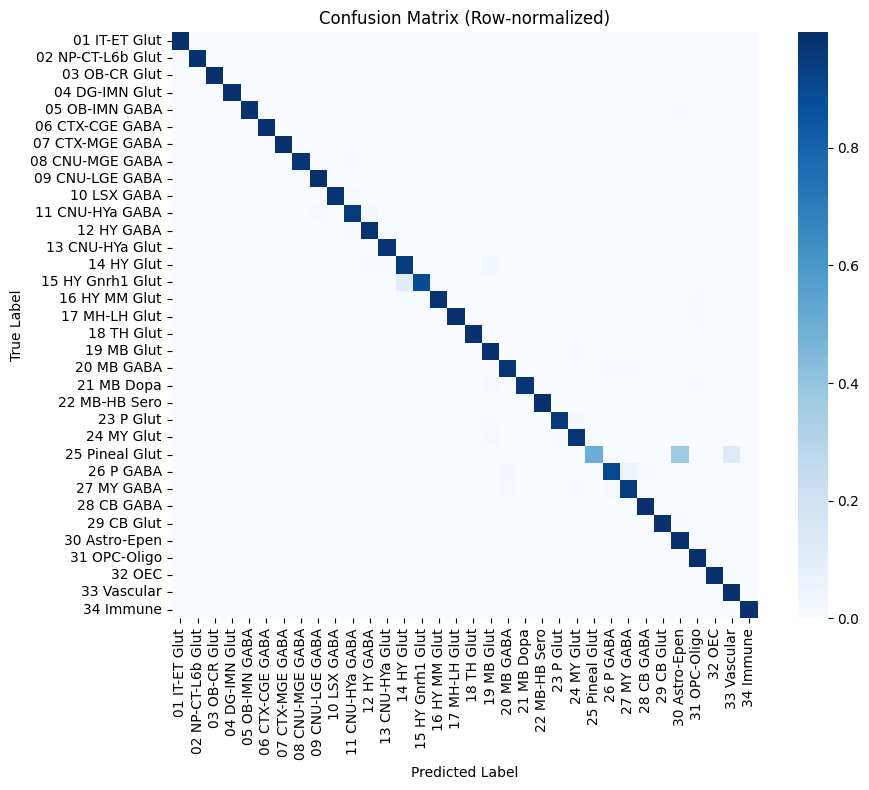

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# pred_labels: shape [num_samples]
# y_val: true labels
# le: LabelEncoder

# 1. 获取原始 confusion matrix
cm = confusion_matrix(y_val, pred_labels)

# 2. 行归一化（每行除以行和）
cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

# 3. 类别标签
class_names = le.classes_

# 4. 画图
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, cmap="Blues", cbar=True,
            xticklabels=class_names, yticklabels=class_names,
            square=True, annot=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Row-normalized)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


In [ ]:
result_df = pd.DataFrame(probs_np, columns=[f'prob_class{i}' for i in range(probs_np.shape[1])])
result_df['x'] = df['x'].values
result_df['y'] = df['y'].values
result_df['region'] = df['brain_section_label'].values

result_df = result_df[['x', 'y', 'region'] + [f'prob_class{i}' for i in range(probs_np.shape[1])]]
result_df.head()


,x,y,region,prob_class0,prob_class1,prob_class2,prob_class3,prob_class4,prob_class5,prob_class6,...,prob_class24,prob_class25,prob_class26,prob_class27,prob_class28,prob_class29,prob_class30,prob_class31,prob_class32,prob_class33
0,7.226245,4.148963,C57BL6J-638850.37,1.927099e-09,3.781083e-12,9.311450e-14,1.852239e-11,1.029323e-11,2.121954e-08,2.502194e-09,...,1.454001e-17,7.000345e-13,4.265027e-11,2.959825e-11,7.599372e-12,2.980845e-10,9.671267e-10,5.969043e-14,2.474169e-10,5.037031e-11
1,5.064889,7.309543,C57BL6J-638850.26,7.244315e-15,2.241662e-13,2.642965e-14,4.860020e-16,8.549650e-13,6.029579e-14,6.194187e-13,...,4.559699e-17,3.073494e-13,7.587775e-16,1.196050e-09,2.882248e-12,1.000000e+00,3.263926e-10,1.095314e-16,6.901962e-13,7.540100e-14
2,5.792921,8.189973,C57BL6J-638850.25,3.843981e-14,4.049844e-14,3.341884e-16,5.545728e-15,3.058110e-13,1.022131e-14,1.118308e-15,...,3.312888e-27,1.135493e-16,1.569736e-17,1.087890e-15,1.616683e-16,6.087821e-14,1.349200e-13,6.360091e-18,1.147162e-14,7.188350e-15
3,3.195950,5.868655,C57BL6J-638850.13,1.648399e-07,9.999998e-01,7.968715e-11,1.201407e-09,5.434015e-11,5.493754e-10,2.131734e-10,...,5.244075e-18,1.835307e-12,5.096627e-13,3.392317e-12,2.773825e-11,2.552222e-10,7.002663e-08,2.669128e-12,7.464262e-10,1.746437e-10
4,5.635732,7.995842,C57BL6J-638850.27,6.095917e-11,1.727110e-11,1.470180e-12,3.163194e-12,5.669218e-13,7.273674e-13,8.856925e-12,...,9.081244e-15,2.251490e-15,1.802689e-15,6.353297e-12,2.123021e-11,2.044187e-08,1.360075e-10,1.640419e-10,1.000000e+00,2.800630e-11


In [ ]:
result_df.to_csv("drive/MyDrive/merfish_cell_embeddings.csv", index=False)

## Dimensional Reduction Network with Grid Search CV
We want to map the GCN's embeddings down to 3 dimensions for RGB-like representation, so our bottleneck dimension is 3. We accomplish this via an Autoencoder trained on MSE reconstruction.

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
result_df = pd.read_csv("drive/MyDrive/DISCO_USECASES/merfish_cell_embeddings.csv")
#result_df.head()

In [ ]:
result_df.shape

(3938808, 37)

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim=34, bottleneck_dim=3, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), int(hidden_dim)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim)),
            nn.Linear(hidden_dim, int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim)),
            nn.Linear(hidden_dim, int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), in_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)


In [4]:
# Dataset of all emebddings
emb_matrix = result_df[[col for col in result_df.columns if col.startswith("prob_")]].values # shape = [N, hidden_dim], N = total nodes from all graphs
emb_matrix_tensor = torch.tensor(emb_matrix, dtype=torch.float32)
emb_matrix_tensor

tensor([[1.9271e-09, 3.7811e-12, 9.3115e-14,  ..., 5.9690e-14, 2.4742e-10,
         5.0370e-11],
        [7.2443e-15, 2.2417e-13, 2.6430e-14,  ..., 1.0953e-16, 6.9020e-13,
         7.5401e-14],
        [3.8440e-14, 4.0498e-14, 3.3419e-16,  ..., 6.3601e-18, 1.1472e-14,
         7.1884e-15],
        ...,
        [4.6307e-08, 1.0000e+00, 3.8727e-11,  ..., 7.6787e-13, 6.6609e-10,
         1.6337e-10],
        [2.0979e-08, 4.6660e-09, 1.9040e-09,  ..., 2.7462e-08, 9.9997e-01,
         4.7304e-09],
        [1.9270e-09, 3.6567e-10, 6.3017e-11,  ..., 1.2249e-10, 1.7478e-10,
         7.9149e-11]])

In [ ]:
print(emb_matrix_tensor.min(), emb_matrix_tensor.max())
print(emb_matrix_tensor.sum(dim=1).mean())


tensor(0.) tensor(1.)
tensor(1.)


In [ ]:
def cluster_contrastive_loss(z, orig_probs, margin=50.0):
    labels = orig_probs.argmax(dim=1)
    B = z.size(0)
    dists = torch.cdist(z, z, p=2)     # [B, B]
    same = (labels.unsqueeze(1) == labels.unsqueeze(0))  # [B,B]
    diff = ~same
    # 类内距离和
    intra_loss = dists[same].sum() / (same.sum() + 1e-8)
    # 类间margin
    inter_loss = torch.clamp(margin - dists[diff], min=0).sum() / (diff.sum() + 1e-8)
    return intra_loss + inter_loss


In [ ]:
def loss_function(orig_probs, pred_logits, z, margin=50.0, beta=0.5):
    pred_log_probs = F.log_softmax(pred_logits, dim=1)
    recon_loss = F.kl_div(pred_log_probs, orig_probs, reduction='batchmean')
    cluster_loss = cluster_contrastive_loss(z, orig_probs, margin)
    total_loss = 0.5 * recon_loss + beta * cluster_loss
    return total_loss, recon_loss.item(), cluster_loss.item()

In [5]:
from torch.utils.data import random_split, DataLoader, TensorDataset

# 假设 emb_matrix_tensor.shape = [N, D]
dataset = TensorDataset(emb_matrix_tensor)

# 划分比例
val_ratio = 0.1
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoader
batch_size = 4096
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
model = Autoencoder()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model = model.to(device)

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_div = 0
    correct = 0
    total = 0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        z, out = model(x)
        loss, recon_loss, diversity_loss = loss_function(x, out, z)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss
        total_div += diversity_loss

        pred = out.argmax(dim=1)
        true = x.argmax(dim=1)
        correct += (pred == true).sum().item()
        total += x.size(0)

    train_acc = correct / total

    # ---------- 验证集 ----------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            z, out = model(x)
            loss, _, _ = loss_function(x, out, z)
            val_loss += loss.item()

            pred = out.argmax(dim=1)
            true = x.argmax(dim=1)
            val_correct += (pred == true).sum().item()
            val_total += x.size(0)

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {total_loss:.4f} | Recon: {total_recon:.4f} | Div: {total_div:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10 | Train Loss: 14.7007 | Recon: 16.1931 | Div: 13.2083 | Train Acc: 0.9998 | Val Loss: 1.7981 | Val Acc: 0.9998
Epoch 2/10 | Train Loss: 15.2974 | Recon: 16.0558 | Div: 14.5391 | Train Acc: 0.9998 | Val Loss: 1.6930 | Val Acc: 0.9998
Epoch 3/10 | Train Loss: 14.7198 | Recon: 16.3002 | Div: 13.1395 | Train Acc: 0.9998 | Val Loss: 1.7911 | Val Acc: 0.9997


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'drive/MyDrive/newaem1.pth')

In [5]:
model = Autoencoder()
model.load_state_dict(torch.load('drive/MyDrive/newaem1.pth'))

<All keys matched successfully>

In [6]:
import torch
import numpy as np
from tqdm import tqdm  # 可选，用于显示进度条

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 1024   # 根据显存调整：减小可以降低显存占用，但会慢一些
use_fp16 = False    # 如果你的 encoder 支持，可尝试 True 来节省显存（用 AMP）

# emb_matrix 可以是 numpy array 或 torch.tensor
if isinstance(emb_matrix, np.ndarray):
    total = emb_matrix.shape[0]
else:
    total = emb_matrix.size(0)

model = model.to(device)
model.eval()

all_outputs = []
with torch.no_grad():
    # 如果想用 autocast 来启用混合精度（节省显存），包在这里
    for start in tqdm(range(0, total, batch_size), desc="encoding batches"):
        end = min(start + batch_size, total)

        # prepare batch as float32 tensor on GPU (pin_memory / DataLoader 可选)
        if isinstance(emb_matrix, np.ndarray):
            batch = torch.tensor(emb_matrix[start:end], dtype=torch.float32, device=device)
        else:
            batch = emb_matrix[start:end].to(device, dtype=torch.float32)

        if use_fp16 and device.startswith("cuda"):
            # 如果要尝试 fp16，并且模型/encoder 支持
            with torch.cuda.amp.autocast():
                z_batch = model.encoder(batch)
        else:
            z_batch = model.encoder(batch)

        # 立即把结果搬回 CPU numpy，释放 GPU 内存
        all_outputs.append(z_batch.detach().cpu().numpy())

        # 清理
        del z_batch, batch
        # 释放显存碎片（可选）
        torch.cuda.empty_cache()

# 合并所有 batch 的结果
z_3d = np.concatenate(all_outputs, axis=0)  # shape [N, 3] (或 encoder 输出的维度)
del all_outputs

# --- 原本的 min-max 缩放与保存流程 ---
min_vals = z_3d.min(axis=0)
max_vals = z_3d.max(axis=0)
print(min_vals, max_vals)
range_vals = (max_vals - min_vals)
range_vals[range_vals == 0] = 1e-9
scaled_3d = (z_3d - min_vals) / range_vals  # [0, 1]
rgb_3d = (scaled_3d * 255).astype(np.uint8)

result_df["R"] = rgb_3d[:, 0]
result_df["G"] = rgb_3d[:, 1]
result_df["B"] = rgb_3d[:, 2]

# 保存（如果数据很大，也可以分块写入 CSV）
# result_df.to_csv("drive/MyDrive/node_embeddings_3d.csv", index=False)


encoding batches: 100%|██████████| 3847/3847 [00:04<00:00, 868.47it/s]


[-84.5987  -86.36052 -74.5089 ] [87.49823 91.5325  71.96337]


## Normalize Outputs to RBG and Save as CSV

In [8]:
model.eval()
with torch.no_grad():
    x_in = torch.tensor(emb_matrix, dtype=torch.float32).to("cuda")
    model = model.to("cuda")
    z_3d = model.encoder(x_in).cpu().numpy()  # shape [N, 3]

# z_3d can have arbitrary range; let's min-max scale each dimension
min_vals = z_3d.min(axis=0)
max_vals = z_3d.max(axis=0)
print(min_vals, max_vals)

# Avoid zero-division if max == min
range_vals = (max_vals - min_vals)
range_vals[range_vals == 0] = 1e-9

scaled_3d = (z_3d - min_vals) / range_vals  # [0, 1]
rgb_3d = (scaled_3d * 255).astype(np.uint8) # [0..255]

# Add columns back to df
result_df["R"] = rgb_3d[:, 0]
result_df["G"] = rgb_3d[:, 1]
result_df["B"] = rgb_3d[:, 2]

# Save to csv
#result_df.to_csv("drive/MyDrive/node_embeddings_3d.csv", index=False)


OutOfMemoryError: CUDA out of memory. Tried to allocate 7.51 GiB. GPU 0 has a total capacity of 14.74 GiB of which 6.58 GiB is free. Process 16148 has 8.16 GiB memory in use. Of the allocated memory 8.02 GiB is allocated by PyTorch, and 14.90 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# To get these constants for image_decoder.ipynb
result_df.head()

,x,y,region,prob_class0,prob_class1,prob_class2,prob_class3,prob_class4,prob_class5,prob_class6,...,prob_class27,prob_class28,prob_class29,prob_class30,prob_class31,prob_class32,prob_class33,R,G,B
0,7.226245,4.148963,C57BL6J-638850.37,1.927099e-09,3.781083e-12,9.311450e-14,1.852239e-11,1.029323e-11,2.121954e-08,2.502194e-09,...,2.959825e-11,7.599372e-12,2.980845e-10,9.671267e-10,5.969043e-14,2.474170e-10,5.037031e-11,237,110,173
1,5.064889,7.309543,C57BL6J-638850.26,7.244315e-15,2.241662e-13,2.642965e-14,4.860020e-16,8.549650e-13,6.029579e-14,6.194187e-13,...,1.196050e-09,2.882248e-12,1.000000e+00,3.263926e-10,1.095314e-16,6.901962e-13,7.540100e-14,68,131,157
2,5.792921,8.189973,C57BL6J-638850.25,3.843981e-14,4.049844e-14,3.341884e-16,5.545728e-15,3.058110e-13,1.022131e-14,1.118308e-15,...,1.087890e-15,1.616683e-16,6.087821e-14,1.349200e-13,6.360091e-18,1.147162e-14,7.188350e-15,122,166,229
3,3.195950,5.868655,C57BL6J-638850.13,1.648399e-07,9.999998e-01,7.968715e-11,1.201407e-09,5.434015e-11,5.493754e-10,2.131734e-10,...,3.392317e-12,2.773825e-11,2.552222e-10,7.002663e-08,2.669128e-12,7.464262e-10,1.746437e-10,111,50,144
4,5.635732,7.995842,C57BL6J-638850.27,6.095917e-11,1.727111e-11,1.470180e-12,3.163194e-12,5.669218e-13,7.273674e-13,8.856925e-12,...,6.353297e-12,2.123021e-11,2.044186e-08,1.360075e-10,1.640419e-10,1.000000e+00,2.800630e-11,76,93,78


## Save individual images as PNG

In [8]:
import cv2
import os
import numpy as np

save_dir = "drive/MyDrive/merfish_region_images_512"
os.makedirs(save_dir, exist_ok=True)

canvas_large = 768   # 初始绘制面板大小
crop_size = 512      # 最终裁剪尺寸
all_regions = result_df["region"].unique()

for cnt, reg in enumerate(all_regions):
    subset = result_df[result_df["region"] == reg]
    xs = subset["x"].values
    ys = subset["y"].values
    Rs = subset["R"].values
    Gs = subset["G"].values
    Bs = subset["B"].values

    print(f"\nRegion {cnt}:")
    print(f"  x range: {xs.min():.2f} → {xs.max():.2f}")
    print(f"  y range: {ys.min():.2f} → {ys.max():.2f}")
    print(f"  Total points: {len(xs)}")

    # ---------- Step 1: 映射到 768×768 ----------
    xs_shifted = xs - xs.min()
    ys_shifted = ys - ys.min()
    width = xs_shifted.max()
    height = ys_shifted.max()

    # 拉伸填满整个画布（不保持比例）
    xs_scaled = xs_shifted * ((canvas_large - 1) / width)
    ys_scaled = ys_shifted * ((canvas_large - 1) / height)

    # ---------- Step 2: 绘制到 768×768 ----------
    img_large = np.ones((canvas_large, canvas_large, 3), dtype=np.uint8) * 255

    filled_pixels = set()
    for i in range(len(subset)):
        x_int = int(round(xs_scaled[i]))
        y_int = int(round(ys_scaled[i]))
        if 0 <= x_int < canvas_large and 0 <= y_int < canvas_large:
            coord = (x_int, y_int)
            filled_pixels.add(coord)
            img_large[y_int, x_int, 0] = Bs[i]
            img_large[y_int, x_int, 1] = Gs[i]
            img_large[y_int, x_int, 2] = Rs[i]

    # ---------- Step 3: 裁剪中间 512×512 ----------
    start = (canvas_large - crop_size) // 2
    end = start + crop_size
    img_crop = img_large[start:end, start:end]

    # ---------- Step 4: 计算保留率 ----------
    # 统计落在中间区域内的唯一像素数
    retained = sum(
        (start <= x < end) and (start <= y < end)
        for x, y in filled_pixels
    )
    total_points = len(subset)
    retain_ratio = retained / total_points * 100

    print(f"  Unique drawn pixels (total): {len(filled_pixels)}")
    print(f"  Pixels in central 512x512: {retained}")
    print(f"  Retain ratio: {retain_ratio:.2f}%")

    # ---------- Step 5: 保存 ----------
    save_path = os.path.join(save_dir, f"region_{cnt}.png")
    cv2.imwrite(save_path, img_crop)
    print(f"  Saved: {save_path} (size={crop_size}x{crop_size})")



Region 0:
  x range: 0.46 → 10.62
  y range: 1.75 → 8.42
  Total points: 90145
  Unique drawn pixels (total): 87392
  Pixels in central 512x512: 53358
  Retain ratio: 59.19%
  Saved: drive/MyDrive/merfish_region_images_512/region_0.png (size=512x512)

Region 1:
  x range: 0.56 → 10.02
  y range: 2.66 → 8.34
  Total points: 79307
  Unique drawn pixels (total): 78010
  Pixels in central 512x512: 44852
  Retain ratio: 56.55%
  Saved: drive/MyDrive/merfish_region_images_512/region_1.png (size=512x512)

Region 2:
  x range: 0.84 → 9.95
  y range: 2.54 → 8.43
  Total points: 73779
  Unique drawn pixels (total): 72945
  Pixels in central 512x512: 40449
  Retain ratio: 54.82%
  Saved: drive/MyDrive/merfish_region_images_512/region_2.png (size=512x512)

Region 3:
  x range: 0.62 → 9.65
  y range: 2.20 → 8.22
  Total points: 71231
  Unique drawn pixels (total): 67112
  Pixels in central 512x512: 41829
  Retain ratio: 58.72%
  Saved: drive/MyDrive/merfish_region_images_512/region_3.png (size=512

In [ ]:
# Save Models
import torch

# Save the classification model's parameters
torch.save(model.state_dict(), "gnn_model.pth")

# Save the autoencoder's parameters
torch.save(autoenc.state_dict(), "autoencoder.pth")